# Introduction to Single-Cell Perturbation Analysis


Single-cell perturbation analysis is a framework for identifying how a biological treatment, stimulus, or genetic perturbation affects cellular states at the single-cell level. Rather than comparing bulk averages between treated and control samples, this approach leverages single-cell resolution to quantify subtle and cell-type–specific responses to a perturbation.

Perturbation analysis in single-cell data often revolves around the idea of separability: if a perturbation, could be checical, biological or genetic (CRISPRi) has a strong effect on a given cell population, it should be easy to distinguish treated from untreated cells based on their transcriptomes. Conversely, if the perturbation barely affects a cell type, classification between treated and untreated will be difficult.

In our case, we have two single-cell RNA-seq datasets: one representing cells exposed to interferon beta (IFN-β) after 6 hours and another representing unexposed control cells. The goal is to determine which cell types are most responsive to interferon signaling and how strongly their transcriptional profiles shift in response.


### Installations

In [ ]:
!pip install scanpy
!pip install anndata
!pip3 install igraph
!pip install celltypist
!pip install decoupler
!pip install fa2-modified
!pip install louvain
!pip install pertpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.4/276.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 64.3 MB/s eta 0:00:00
  Attempting uninstall: igraph
    Found existing installation: igraph 1.0.0
    Uninstalling igraph-1.0.0:
      Successfully uninstalled igra

In [ ]:
!pip install harmonypy

### Import Libraries

In [ ]:
#Import core single cell datasets

import scanpy as sc
import anndata as ad
import numpy as np
import pertpy as pt
import pandas as pd


### Download the cells without IFN stimulation

In [ ]:
!wget https://github.com/josoga2/sc/raw/refs/heads/main/GSE96583_RAW/GSM2560249_2.2.mtx.gz
!wget https://github.com/josoga2/sc/raw/refs/heads/main/GSE96583_RAW/GSM2560249_barcodes.tsv.gz
!wget https://github.com/josoga2/sc/raw/refs/heads/main/GSE96583_RAW/GSE96583_batch2.genes.tsv.gz

--2025-10-29 04:32:30--  https://github.com/josoga2/sc/raw/refs/heads/main/GSE96583_RAW/GSM2560249_2.2.mtx.gz
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/josoga2/sc/refs/heads/main/GSE96583_RAW/GSM2560249_2.2.mtx.gz [following]
--2025-10-29 04:32:30--  https://raw.githubusercontent.com/josoga2/sc/refs/heads/main/GSE96583_RAW/GSM2560249_2.2.mtx.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29050932 (28M) [application/octet-stream]
Saving to: ‘GSM2560249_2.2.mtx.gz’

GSM2560249_2.2.mtx. 100%[===================>]  27.71M  66.2MB/s    in 0.4s    

2025-10-29 04:32:33 (66.2 MB/s) - ‘GSM25

In [ ]:
!mkdir -p GSM2560245_Before
!mv GSM2560249_2.2.mtx.gz /content/GSM2560245_Before
!mv GSM2560249_barcodes.tsv.gz /content/GSM2560245_Before
!mv GSE96583_batch2.genes.tsv.gz /content/GSM2560245_Before

#rename files to matrix, barcode and genes
!mv /content/GSM2560245_Before/GSM2560249_2.2.mtx.gz /content/GSM2560245_Before/matrix.mtx.gz
!mv /content/GSM2560245_Before/GSM2560249_barcodes.tsv.gz /content/GSM2560245_Before/barcodes.tsv.gz
!mv /content/GSM2560245_Before/GSE96583_batch2.genes.tsv.gz /content/GSM2560245_Before/genes.tsv.gz

### Download the cells with IFN stimulation after 6 hrs

In [ ]:
!wget https://github.com/josoga2/sc/raw/refs/heads/main/GSE96583_RAW/GSM2560248_2.1.mtx.gz
!wget https://github.com/josoga2/sc/raw/refs/heads/main/GSE96583_RAW/GSM2560248_barcodes.tsv.gz
!wget https://github.com/josoga2/sc/raw/refs/heads/main/GSE96583_RAW/GSE96583_batch2.genes.tsv.gz

--2025-10-29 04:32:36--  https://github.com/josoga2/sc/raw/refs/heads/main/GSE96583_RAW/GSM2560248_2.1.mtx.gz
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/josoga2/sc/refs/heads/main/GSE96583_RAW/GSM2560248_2.1.mtx.gz [following]
--2025-10-29 04:32:36--  https://raw.githubusercontent.com/josoga2/sc/refs/heads/main/GSE96583_RAW/GSM2560248_2.1.mtx.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28545918 (27M) [application/octet-stream]
Saving to: ‘GSM2560248_2.1.mtx.gz’

GSM2560248_2.1.mtx. 100%[===================>]  27.22M  65.5MB/s    in 0.4s    

2025-10-29 04:32:38 (65.5 MB/s) - ‘GSM25

In [ ]:
!mkdir -p GSM2560245_After
!mv GSM2560248_2.1.mtx.gz /content/GSM2560245_After
!mv GSM2560248_barcodes.tsv.gz /content/GSM2560245_After
!mv GSE96583_batch2.genes.tsv.gz /content/GSM2560245_After

#rename the files accordingly
!mv /content/GSM2560245_After/GSM2560248_2.1.mtx.gz /content/GSM2560245_After/matrix.mtx.gz
!mv /content/GSM2560245_After/GSM2560248_barcodes.tsv.gz /content/GSM2560245_After/barcodes.tsv.gz
!mv /content/GSM2560245_After/GSE96583_batch2.genes.tsv.gz /content/GSM2560245_After/genes.tsv.gz

In [ ]:
#write a function for assembling the dataset

def load_one_dataset(path, condition_label):
    # Read matrix
    adata = sc.read_mtx(f"{path}/matrix.mtx.gz").T

    # Read barcodes
    adata.obs_names = pd.read_csv(f"{path}/barcodes.tsv.gz", header=None, sep="\t")[0]

    # Read and clean genes
    genes = pd.read_csv(f"{path}/genes.tsv.gz", header=None, sep = '\t')[1]
    #print(genes.head())
    genes = genes.astype(str).str.replace(r'^\d+"', '', regex=True)
    adata.var_names = genes.var_names = genes[:adata.shape[1]]

    #make unique
    adata.var_names_make_unique()
    adata.obs_names_make_unique()

    # Add condition label
    adata.obs["condition"] = condition_label

    return adata

In [ ]:
adata_before = load_one_dataset("/content/GSM2560245_After", "before_IFN_beta")
adata_after = load_one_dataset("/content/GSM2560245_Before", "after_IFN_beta")

In [ ]:
ifn_adata = adata_before.concatenate(adata_after, batch_key="condition",
                                 batch_categories=["before_IFN_beta", "after_IFN_beta"])

/tmp/ipython-input-7954371.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  ifn_adata = adata_before.concatenate(adata_after, batch_key="condition",


In [ ]:
ifn_adata.var.head()

""
MIR1302-10
FAM138A
OR4F5
RP11-34P13.7
RP11-34P13.8


### The Core Pipeline!

In [ ]:
ifn_adata.var['MT'] = ifn_adata.var_names.str.startswith("MT-")
ifn_adata.var['RIBO'] = ifn_adata.var_names.str.startswith("RPS", "RPL")
ifn_adata.var['HB'] = ifn_adata.var_names.str.startswith("^HB[^(P)]")

In [ ]:
sc.pp.calculate_qc_metrics(
    ifn_adata, qc_vars=["MT", 'RIBO', 'HB'], inplace=True, log1p=True
)

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (5,4)  # Adjust figure size
plt.rcParams["axes.grid"] = True  # Add grid to plots
plt.rcParams["axes.edgecolor"] = "black" # Set plot border color
plt.rcParams["axes.linewidth"] = 1.5 # Set plot border width
plt.rcParams["axes.facecolor"] = "white" # Set background color
plt.rcParams["axes.labelcolor"] = "black" # Set label color
plt.rcParams["xtick.color"] = "black" # Set x-axis tick color
plt.rcParams["ytick.color"] = "black" # Set y-axis tick color
plt.rcParams["text.color"] = "black" # Set text color
%matplotlib inline

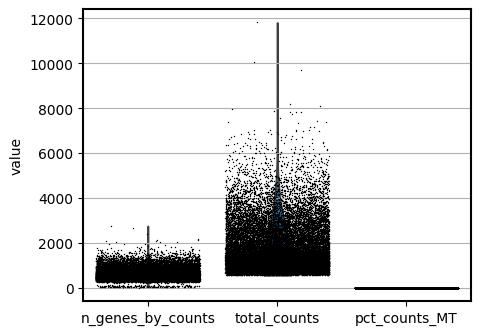

In [ ]:
sc.pl.violin(
    ifn_adata,
    ["n_genes_by_counts", 'total_counts', 'pct_counts_MT'],
    jitter=0.4,
    multi_panel=False,
)



In [ ]:
ifn_adata.obs_keys()

/tmp/ipython-input-969156741.py:1: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  ifn_adata.obs_keys()


['condition',
 'n_genes_by_counts',
 'log1p_n_genes_by_counts',
 'total_counts',
 'log1p_total_counts',
 'pct_counts_in_top_50_genes',
 'pct_counts_in_top_100_genes',
 'pct_counts_in_top_200_genes',
 'pct_counts_in_top_500_genes',
 'total_counts_MT',
 'log1p_total_counts_MT',
 'pct_counts_MT',
 'total_counts_RIBO',
 'log1p_total_counts_RIBO',
 'pct_counts_RIBO',
 'total_counts_HB',
 'log1p_total_counts_HB',
 'pct_counts_HB']

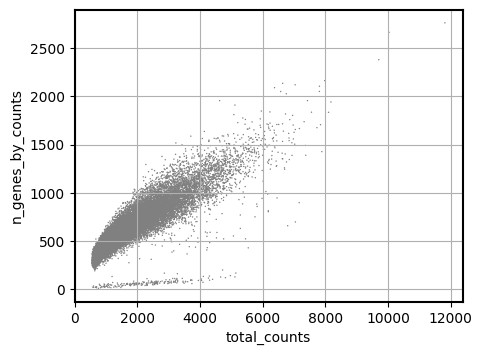

In [ ]:
sc.pl.scatter(ifn_adata, "total_counts", "n_genes_by_counts")

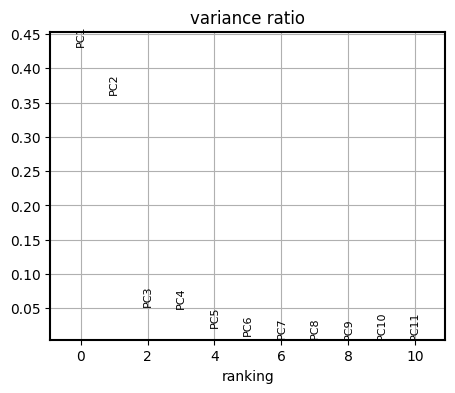

In [ ]:
#Dim Reduction
sc.tl.pca(ifn_adata)
sc.pl.pca_variance_ratio(ifn_adata, n_pcs=10, log=False)

In [ ]:
#Let's correct for batch effect
import scanpy.external as sce
sce.pp.harmony_integrate(ifn_adata, key="condition")

2025-10-29 04:33:33,670 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
INFO:harmonypy:Computing initial centroids with sklearn.KMeans...
2025-10-29 04:33:44,843 - harmonypy - INFO - sklearn.KMeans initialization complete.
INFO:harmonypy:sklearn.KMeans initialization complete.
2025-10-29 04:33:45,155 - harmonypy - INFO - Iteration 1 of 10
INFO:harmonypy:Iteration 1 of 10
2025-10-29 04:33:58,817 - harmonypy - INFO - Iteration 2 of 10
INFO:harmonypy:Iteration 2 of 10
2025-10-29 04:34:11,578 - harmonypy - INFO - Iteration 3 of 10
INFO:harmonypy:Iteration 3 of 10
2025-10-29 04:34:23,723 - harmonypy - INFO - Converged after 3 iterations
INFO:harmonypy:Converged after 3 iterations


In [ ]:
#Normalisation
ifn_adata.layers["counts"] = ifn_adata.X.copy()
sc.pp.normalize_total(ifn_adata)
sc.pp.log1p(ifn_adata)

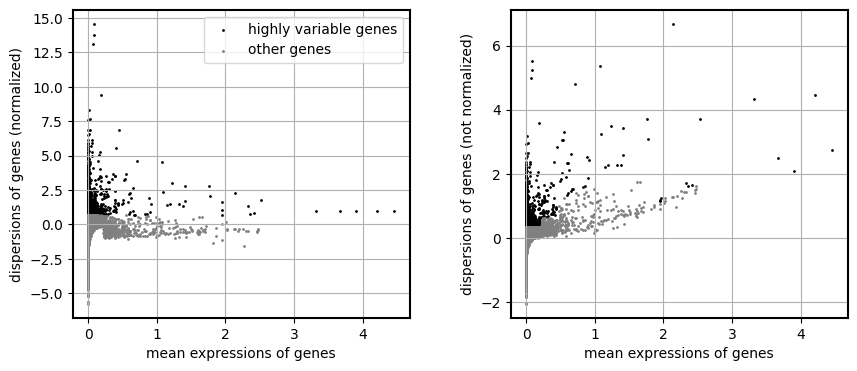

In [ ]:
#Feature selection
sc.pp.highly_variable_genes(ifn_adata, n_top_genes=2500)
sc.pl.highly_variable_genes(ifn_adata)

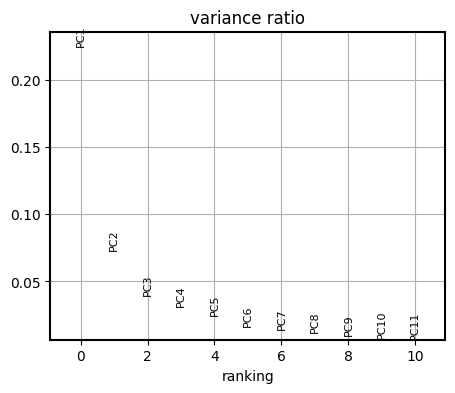

In [ ]:
#Dim Reduction
sc.tl.pca(ifn_adata)
sc.pl.pca_variance_ratio(ifn_adata, n_pcs=10, log=False)


In [ ]:
ifn_adata.var_names

Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8',
       'AL627309.1', 'RP11-34P13.14', 'RP11-34P13.9', 'AP006222.2',
       'RP4-669L17.10',
       ...
       'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4',
       'MT-ND5', 'MT-ND6', 'MT-CYB'],
      dtype='object', length=35635)

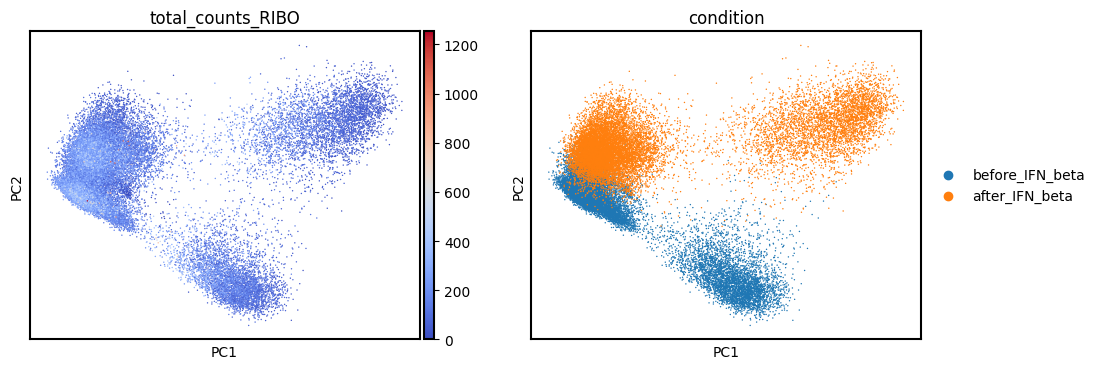

In [ ]:
sc.pl.pca(ifn_adata, cmap="coolwarm", color = ['total_counts_RIBO', 'condition'])

In [ ]:
sc.pp.neighbors(ifn_adata)
sc.tl.umap(ifn_adata)

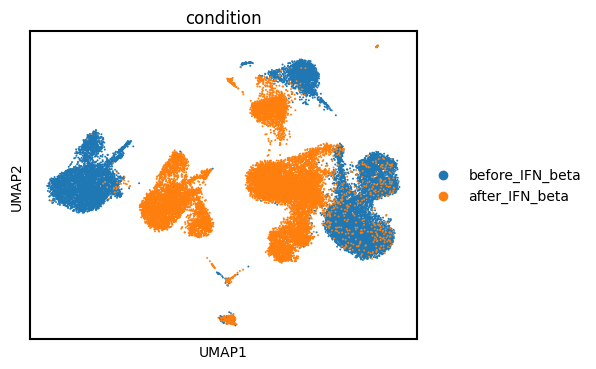

In [ ]:
sc.pl.umap(
    ifn_adata,
    size=8,
    color=["condition"],
)

In [ ]:
sc.tl.leiden(ifn_adata, flavor="igraph", n_iterations=10, key_added="leiden_res_", resolution=0.5 )

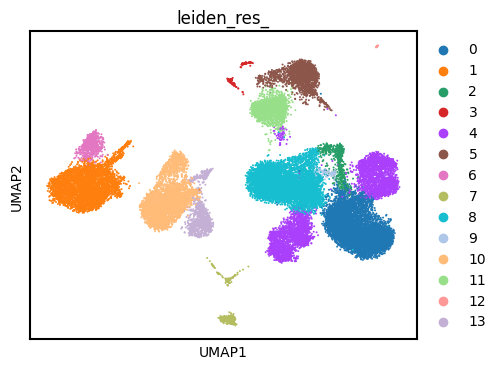

In [ ]:
sc.pl.umap(
    ifn_adata,
    color=["leiden_res_"],
    size=8,
)

In [ ]:
import decoupler as dc

In [ ]:
#!wget wget -O result.txt 'http://www.ensembl.org/biomart/martservice?query=<?xml version="1.0" encoding="UTF-8"?><!DOCTYPE Query><Query  virtualSchemaName = "default" formatter = "CSV" header = "0" uniqueRows = "0" count = "" datasetConfigVersion = "0.6" ><Dataset name = "hsapiens_gene_ensembl" interface = "default" ><Attribute name = "ensembl_gene_id" /><Attribute name = "external_gene_name" /></Dataset></Query>'

In [ ]:
#import pandas as pd
#ensembl_var = pd.read_csv('/content/result.txt', header = None)
#ensembl_var.columns = ['ensembl_gene_id', 'gene_name']
#ensembl_var.head(3)

In [ ]:
# Query Omnipath and get PanglaoDB
markers = dc.op.resource(name="PanglaoDB", organism="human")

# Remove duplicated entries
markers = markers[~markers.duplicated(["cell_type", "genesymbol"])]

#Format because dc only accepts cell_type and genesymbol

markers = markers.rename(columns={"cell_type": "source", "genesymbol": "target"})
markers = markers[["source", "target"]]


markers.head()

,source,target
,,
0,Hepatocytes,A1CF
1,Germ cells,A2APA5
2,Bergmann glia,A2M
3,Mast cells,A3FIN4
4,Mast cells,A4GALT


In [ ]:
ifn_adata.var_names

Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8',
       'AL627309.1', 'RP11-34P13.14', 'RP11-34P13.9', 'AP006222.2',
       'RP4-669L17.10',
       ...
       'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4',
       'MT-ND5', 'MT-ND6', 'MT-CYB'],
      dtype='object', length=35635)

In [ ]:
dc.mt.ulm(data=ifn_adata,
          net=markers,
          tmin = 3)

In [ ]:
score = dc.pp.get_obsm(ifn_adata, key="score_ulm")

In [ ]:
ifn_adata.obsm["score_ulm"].head(1)

,Acinar cells,Adipocyte progenitor cells,Adipocytes,Adrenergic neurons,Airway goblet cells,Airway smooth muscle cells,Alpha cells,Alveolar macrophages,Anterior pituitary gland cells,Astrocytes,...,Taste receptor cells,Thymocytes,Transient cells,Trichocytes,Trigeminal neurons,Trophoblast cells,Tuft cells,Undefined placental cells,Urothelial cells,Vascular smooth muscle cells
AAACATACAATGCC-1-before_IFN_beta,-0.80043,-0.60492,-1.324387,-0.390399,-0.653424,-0.302386,0.41708,-0.819289,0.63006,0.489759,...,0.162085,2.710003,-0.781119,-0.302386,-0.56289,-0.781119,0.132304,-0.493861,-0.493861,-0.349174


In [ ]:
ifn_adata.obsm["score_ulm"].columns

Index(['Acinar cells', 'Adipocyte progenitor cells', 'Adipocytes',
       'Adrenergic neurons', 'Airway goblet cells',
       'Airway smooth muscle cells', 'Alpha cells', 'Alveolar macrophages',
       'Anterior pituitary gland cells', 'Astrocytes',
       ...
       'Taste receptor cells', 'Thymocytes', 'Transient cells', 'Trichocytes',
       'Trigeminal neurons', 'Trophoblast cells', 'Tuft cells',
       'Undefined placental cells', 'Urothelial cells',
       'Vascular smooth muscle cells'],
      dtype='object', length=168)

In [ ]:
#rank genes
ifn_gene_rank = dc.tl.rankby_group(score, groupby="leiden_res_", reference="rest", method="t-test_overestim_var")
ifn_gene_rank = ifn_gene_rank[ifn_gene_rank["stat"] > 0]
ifn_gene_rank.head(5)

,group,reference,name,stat,meanchange,pval,padj
0,0,rest,T memory cells,42.618747,1.859396,0.000000e+00,0.000000e+00
1,0,rest,Pancreatic progenitor cells,40.358809,1.426236,0.000000e+00,0.000000e+00
2,0,rest,T follicular helper cells,40.199745,0.657304,0.000000e+00,0.000000e+00
27,0,rest,T helper cells,38.039959,0.832729,5.802959e-299,3.481776e-298
29,0,rest,T cells naive,36.946212,2.236368,3.216882e-283,1.801454e-282


In [ ]:
top_names_per_group = ifn_gene_rank.groupby('group')['name'].apply(lambda x: x.head(1))
display(top_names_per_group)

/tmp/ipython-input-4248453526.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_names_per_group = ifn_gene_rank.groupby('group')['name'].apply(lambda x: x.head(1))


,,name
group,,
0,0,T memory cells
1,168,Microfold cells
10,1680,Monocytes
11,1848,B cells
12,2016,Pulmonary alveolar type II cells
13,2184,Monocytes
2,337,Melanocytes
3,504,Plasmacytoid dendritic cells
4,672,NK cells


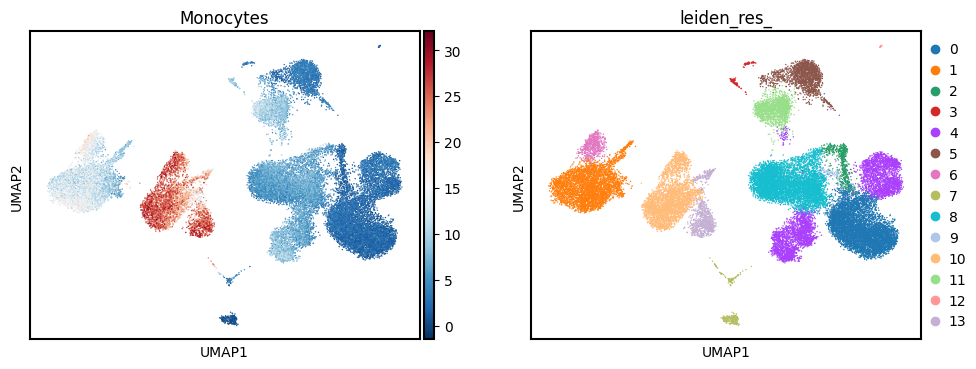

In [ ]:
sc.pl.umap(score, color=["Monocytes", 'leiden_res_'], cmap="RdBu_r")

In [ ]:
n_ctypes = 1
ctypes_dict = ifn_gene_rank.groupby("group").head(n_ctypes).groupby("group")["name"].apply(lambda x: list(x)).to_dict()
ctypes_dict

/tmp/ipython-input-4150618453.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ctypes_dict = ifn_gene_rank.groupby("group").head(n_ctypes).groupby("group")["name"].apply(lambda x: list(x)).to_dict()


{'0': ['T memory cells'],
 '1': ['Microfold cells'],
 '10': ['Monocytes'],
 '11': ['B cells'],
 '12': ['Pulmonary alveolar type II cells'],
 '13': ['Monocytes'],
 '2': ['Melanocytes'],
 '3': ['Plasmacytoid dendritic cells'],
 '4': ['NK cells'],
 '5': ['B cells naive'],
 '6': ['Dendritic cells'],
 '7': ['Erythroid-like and erythroid precursor cells'],
 '8': ['T cells naive'],
 '9': ['Pulmonary alveolar type II cells']}

In [ ]:
dict_ann = ifn_gene_rank[ifn_gene_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()
dict_ann

/tmp/ipython-input-2298216777.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dict_ann = ifn_gene_rank[ifn_gene_rank["stat"] > 0].groupby("group").head(1).set_index("group")["name"].to_dict()


{'0': 'T memory cells',
 '1': 'Microfold cells',
 '2': 'Melanocytes',
 '3': 'Plasmacytoid dendritic cells',
 '4': 'NK cells',
 '5': 'B cells naive',
 '6': 'Dendritic cells',
 '7': 'Erythroid-like and erythroid precursor cells',
 '8': 'T cells naive',
 '9': 'Pulmonary alveolar type II cells',
 '10': 'Monocytes',
 '11': 'B cells',
 '12': 'Pulmonary alveolar type II cells',
 '13': 'Monocytes'}

In [ ]:
dict_ann_unique = {k: v + '_' + str(k) for k, v in dict_ann.items()}
display(dict_ann_unique)

{'0': 'T memory cells_0',
 '1': 'Microfold cells_1',
 '2': 'Melanocytes_2',
 '3': 'Plasmacytoid dendritic cells_3',
 '4': 'NK cells_4',
 '5': 'B cells naive_5',
 '6': 'Dendritic cells_6',
 '7': 'Erythroid-like and erythroid precursor cells_7',
 '8': 'T cells naive_8',
 '9': 'Pulmonary alveolar type II cells_9',
 '10': 'Monocytes_10',
 '11': 'B cells_11',
 '12': 'Pulmonary alveolar type II cells_12',
 '13': 'Monocytes_13'}

In [ ]:
ifn_adata.obs["leiden_res_"] = ifn_adata.obs["leiden_res_"].cat.rename_categories(dict_ann_unique)

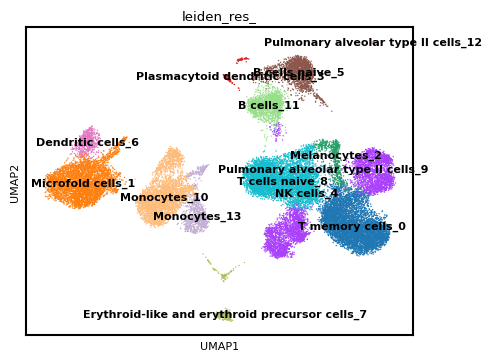

In [ ]:

plt.rcParams["figure.figsize"] = (5,4)  # Adjust figure size
# Reduce the default font size for text elements in plots
plt.rcParams['font.size'] = 8
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8

# Now replot the UMAP
sc.pl.umap(
    adata=ifn_adata,
    color=[ "leiden_res_"],
    ncols=2,
    legend_loc = 'on data',
    size=4,
)

### Perturbation modelling

How it works:
- **Input Data**: A single-cell expression matrix with cell-level metadata indicating the experimental condition (e.g., `condition = ['control', 'IFN_beta']`) and cell type annotations.
- **Subsampling**: To avoid biases due to unequal cell numbers, Augur repeatedly subsamples a fixed number of cells per condition per cell type.
- **Feature Selection**: It selects variable genes to focus on biologically relevant variation.
- **Classification**: For each cell type, Augur trains a machine learning model—typically a random forest—to predict which condition each cell belongs to.
- **Performance Scoring**: The mean AUC across subsampling iterations is computed. A high AUC indicates that the perturbation strongly shifts that cell type’s expression profile, making it easier to classify. A low AUC suggests minimal transcriptional change.



Here, we will use our dataset to know which cells are best targeted during stimulation IFN-β stimulation

In [ ]:
ifn_adata.layers.keys()

KeysView(Layers with keys: counts)

In [ ]:
raw_counts = ifn_adata.layers["counts"]

In [ ]:
raw_counts.shape

(29065, 35635)

In [ ]:
raw_counts

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 17570845 stored elements and shape (29065, 35635)>

In [ ]:
ifn_adata.X = raw_counts

In [ ]:
ifn_adata.obs_keys()

/tmp/ipython-input-969156741.py:1: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  ifn_adata.obs_keys()


['condition',
 'n_genes_by_counts',
 'log1p_n_genes_by_counts',
 'total_counts',
 'log1p_total_counts',
 'pct_counts_in_top_50_genes',
 'pct_counts_in_top_100_genes',
 'pct_counts_in_top_200_genes',
 'pct_counts_in_top_500_genes',
 'total_counts_MT',
 'log1p_total_counts_MT',
 'pct_counts_MT',
 'total_counts_RIBO',
 'log1p_total_counts_RIBO',
 'pct_counts_RIBO',
 'total_counts_HB',
 'log1p_total_counts_HB',
 'pct_counts_HB',
 'leiden_res_']

In [ ]:
ifn_adata.obs["condition"]

,condition
AAACATACAATGCC-1-before_IFN_beta,before_IFN_beta
AAACATACATTTCC-1-before_IFN_beta,before_IFN_beta
AAACATACCAGAAA-1-before_IFN_beta,before_IFN_beta
AAACATACCAGCTA-1-before_IFN_beta,before_IFN_beta
AAACATACCATGCA-1-before_IFN_beta,before_IFN_beta
...,...
TTTGCATGCTAAGC-1-after_IFN_beta,after_IFN_beta
TTTGCATGGGACGA-1-after_IFN_beta,after_IFN_beta
TTTGCATGGTGAGG-1-after_IFN_beta,after_IFN_beta
TTTGCATGGTTTGG-1-after_IFN_beta,after_IFN_beta


In [ ]:
ifn_adata.obs.leiden_res_.value_counts()

,count
leiden_res_,
T memory cells_0,6089
T cells naive_8,5834
NK cells_4,4260
Microfold cells_1,3895
Monocytes_10,3209
B cells naive_5,1708
B cells_11,1477
Monocytes_13,962
Dendritic cells_6,570


In [ ]:
ag_rfc = pt.tl.Augur("random_forest_classifier")

In [ ]:
loaded_data = ag_rfc.load(ifn_adata, label_col="condition", cell_type_col="leiden_res_")
loaded_data

AnnData object with n_obs × n_vars = 29065 × 35635
    obs: 'label', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'total_counts_RIBO', 'log1p_total_counts_RIBO', 'pct_counts_RIBO', 'total_counts_HB', 'log1p_total_counts_HB', 'pct_counts_HB', 'cell_type', 'y_'
    var: 'MT', 'RIBO', 'HB', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    layers: 'counts'

In [ ]:
v_adata, v_results = ag_rfc.predict(
    loaded_data, subsample_size=50, n_threads=4, select_variance_features=True, span=1
)

v_results["summary_metrics"]

! Set smaller span value in the case of a `segmentation fault` error.
! Set larger span in case of svddc or other near singularities error.


Output()

! Skipping Microfold cells_1 cell type - the number of samples for at least one class type is less than subsample size 50.
! Skipping Plasmacytoid dendritic cells_3 cell type - the number of samples for at least one class type is less than subsample size 50.
! Skipping Dendritic cells_6 cell type - the number of samples for at least one class type is less than subsample size 50.
! Skipping Pulmonary alveolar type II cells_9 cell type - the number of samples for at least one class type is less than subsample size 50.
! Skipping Monocytes_10 cell type - the number of samples for at least one class type is less than subsample size 50.
! Skipping B cells_11 cell type - the number of samples for at least one class type is less than subsample size 50.
! Skipping Pulmonary alveolar type II cells_12 cell type - 19 samples is less than min_cells 50.
! Skipping Monocytes_13 cell type - the number of samples for at least one class type is less than subsample size 50.


,T memory cells_0,Melanocytes_2,NK cells_4,B cells naive_5,Erythroid-like and erythroid precursor cells_7,T cells naive_8
mean_augur_score,0.619937,0.647404,0.701807,0.839610,0.539469,0.730509
mean_auc,0.619937,0.647404,0.701807,0.839610,0.539469,0.730509
mean_accuracy,0.575152,0.594575,0.636762,0.758241,0.534528,0.659257
mean_precision,0.627809,0.637931,0.663549,0.720572,0.538655,0.670737
mean_f1,0.466391,0.532513,0.610382,0.781923,0.530117,0.649675
mean_recall,0.393578,0.484093,0.599069,0.865441,0.552843,0.652843


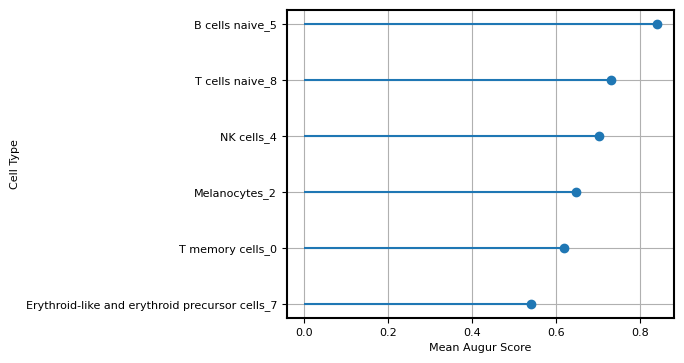

In [ ]:
lollipop = ag_rfc.plot_lollipop(v_results)

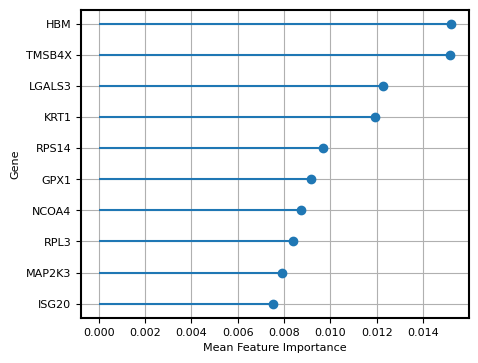

In [ ]:
important_features = ag_rfc.plot_important_features(v_results)